## Import the necessary functions 

In [1]:
# Import the necessary functions

# Personalised functions created for this NN application
from NEMO_NN_functions import *
# To convert from lat lon, to x y
from pyproj import Transformer
# To extract just the bedmachine mask within the NEMO 1 degree grid 
from shapely.geometry import Polygon
from shapely.vectorized import contains
# To extract neighbouring cells
from scipy.ndimage import binary_dilation 
# To plot figures 
import matplotlib.pyplot as plt

# To create the ocean profile 
from scipy.spatial import cKDTree

## Set variables 

In [94]:
# Set the filepaths and any variables 

# NEMO simulation temperature and salinity profiles 
filepath_nemo_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/AIAI_data/ECM71-ico-LR-pi-01.pi_1883_1Y_grid_T.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_y1985.1y_gridT.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.L75-TOTO_1y_NN_1979-1979.nc'
#filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/perfect_BM3/eORCA1.L75-TOTO_1y_gridT_1979-1979.nc'
filepath_nemo_output = '/bettik/ockendeh/NEMO_simulations/perfect_BM3/eORCA1.L75-TOTO_1y_gridT_1980-1980.nc'

# NEMO full grid coords
filepath_domain_cfg = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Set the filepaths 
# The target grid mask 
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
# The target grid geometry
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'
# The eORCA1 bedmachine mask
filepath_eORCA1_bmach_masks = '/bettik/ockendeh/NEMO_simulations/eORCA1_bmach_masks.nc'
filepath_domain_CFG = '/bettik/ockendeh/NEMO_simulations/TGCC/eORCA1.4.3_CavsForNN_domain_cfg.nc'

# Neural network filepaths 
path_model = '/bettik/ockendeh/NEMO_simulations/models/'
path_norm_metrics = '/bettik/ockendeh/NEMO_simulations/models/'

# And the location of the output files 
folder_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/'
simulation = 'DUM002' # Can potentially be set from the input 
year_of_interest = '9999' # Can potentially be set from the input 
filepath_nn_output = folder_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'

# Any parameters which need to be set 
# Which neural network have you chosen?
this_collection = 'OPM026_OPM0263_OPM031_OPM016_OPM018_OPM021_ctrl94_isf94_isfru94'
exp_name = 'slope_front'
join_ice_shelves = False
nemo_version = '5'

## Apply neural network

In [95]:
filepath_nn_output = folder_nn_output + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc'
filepath_nn_output

'/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_output_melt_DUM002_9999.nc'

In [96]:
import time

In [97]:
import glob
glob.glob('/bettik/ockendeh/NEMO_simulations/*geom_vars*.nc')

['/bettik/ockendeh/NEMO_simulations/geom_vars_NEMO025_BMach3_9999pc.nc',
 '/bettik/ockendeh/NEMO_simulations/geom_vars_NEMO025_BMach2_9999pc.nc',
 '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc',
 '/bettik/ockendeh/NEMO_simulations/NEMO025_geom_vars.nc']

In [98]:
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_geometric_masks.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2median_geometric_masks.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_0pc_geometric_masks.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geometric_masks_NEMO025_BMach3_9999pc.nc'
# The target grid geometry
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_geom_vars.nc'
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2median_geom_vars.nc'
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_0pc_geom_vars.nc'
filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/test_mask_geoms/geom_vars_NEMO025_BMach3_9999pc.nc'

In [99]:
mask = xr.open_dataset(filepath_mask)
geomvars = xr.open_dataset(filepath_geomvars)

In [100]:
np.nansum(mask.closed_cavities_nan * geomvars.areas * geomvars.fraction)/1e6

np.float64(398183.1741276217)

In [101]:
area_nemo1 = xr.open_dataset(filepath_nemo_output).area.values

In [102]:
%%time
apply_nn_to_NEMO(filepath_nemo_output, 
                     filepath_mask, 
                     filepath_geomvars, 
                     filepath_eORCA1_bmach_masks, 
                     filepath_domain_CFG,
                     path_model, 
                     path_norm_metrics, 
                     filepath_nn_output = '/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_output_melt_DUM003_9999.nc', 
                     this_collection = this_collection, 
                     exp_name = exp_name, 
                     join_ice_shelves = join_ice_shelves, 
                     verbose = 0, 
                     nemo_version = nemo_version)

You have loaded: /bettik/ockendeh/NEMO_simulations/test_mask_geoms/geom_vars_NEMO025_BMach3_9999pc.nc
You have loaded: /bettik/ockendeh/NEMO_simulations/test_mask_geoms/geometric_masks_NEMO025_BMach3_9999pc.nc
You have loaded coordinates: /bettik/ockendeh/NEMO_simulations/perfect_BM3/eORCA1.L75-TOTO_1y_gridT_1980-1980.nc
Cropped to Antarctica only
You have loaded T and S: /bettik/ockendeh/NEMO_simulations/perfect_BM3/eORCA1.L75-TOTO_1y_gridT_1980-1980.nc
Cropped to Antarctica only
Loaded data. Time: 2.0 s
There are 31 basins with no ocean profiles : [16, 17, 21, 22, 24, 27, 28, 30, 31, 33, 34, 35, 37, 38, 40, 43, 45, 52, 67, 69, 79, 80, 82, 86, 90, 107, 115, 118, 124, 125, 126]
There should be 5 basins (2 with no cavities plus 3 where we merged)
Created T/S profiles. Time: 13.5 s
Prepared data to apply NN. Time: 23.4 s
Applying neural networks
Applied NN. Time: 28.0 s               
You have loaded: /bettik/ockendeh/NEMO_simulations/perfect_BM3/eORCA1.L75-TOTO_1y_gridT_1980-1980.nc
Cro

In [103]:
melt = xr.open_dataset('/bettik/ockendeh/SCRIPTS/simpleNN_basal_melt/data/processing_ho/nn_output_melt_DUM003_9999.nc')# + 'nn_output_melt' '_' + simulation + '_' + year_of_interest + '.nc')
melt_all = melt.melt.values
melt_sum = np.sum(melt_all * area_nemo1 * (60*60*24*265.23)/1e12)
melt.close()
print(melt_sum)

822.3040662814453


In [63]:
pc_allowed_b2 = (0, 20, 60,99)
melt_Gt_b2 = (1098, 1044, 1027, 1013)
pc_allowed_b3 = (0, 20, 60, 99)
melt_Gt_b3 = (1184, 1138, 1119, 1111)
melt_Gt_oldmask = 1019

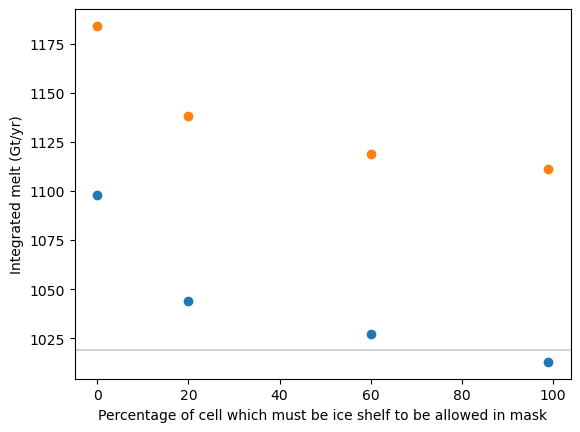

In [68]:
fig, ax = plt.subplots(1,1)
ax.scatter(pc_allowed_b2, melt_Gt_b2)
ax.scatter(pc_allowed_b3, melt_Gt_b3)
ax.set_xlabel('Percentage of cell which must be ice shelf to be allowed in mask')
ax.set_ylabel('Integrated melt (Gt/yr)')
#ax.axhline(1176, color = 'lightgrey')
ax.axhline(melt_Gt_oldmask, color = 'lightgrey')

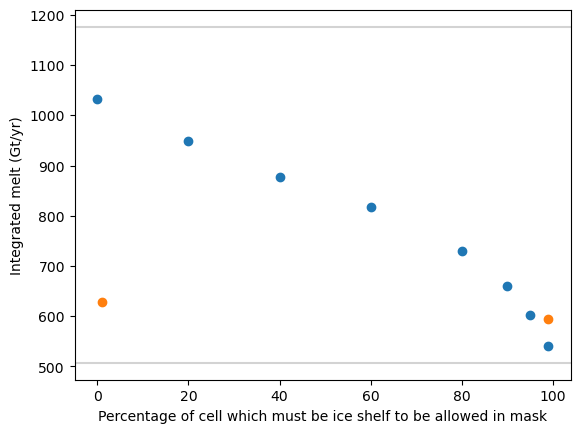

In [128]:
pc_allowed = (99,20, 80, 60, 0, 40, 90, 95) # 40, 90
melt_Gt = (541, 949, 730, 818, 1033, 877, 660, 603) 
pc_allowed_b3 = (1,99)
melt_Gt_b3 = (629, 595)
fig, ax = plt.subplots(1,1)
ax.scatter(pc_allowed, melt_Gt)
ax.scatter(pc_allowed_b3, melt_Gt_b3)
ax.set_xlabel('Percentage of cell which must be ice shelf to be allowed in mask')
ax.set_ylabel('Integrated melt (Gt/yr)')
ax.axhline(1176, color = 'lightgrey')
ax.axhline(507, color = 'lightgrey')

In [36]:
# Old mask == 507 Gt 
# New mask == 1176 Gt
# New mask BM2 = 1096 Gt
# New mask BM2 median = 1105 Gt
# New mask BM2 only >20% ice shelf = 969 Gt
# New mask BM2 only >20% ice shelf (slopes correct way up) = 949 Gt 
# New mask BM2 only 100% ice shelf = 541 Gt 

In [ ]:
# So what is the difference between the Old and new BM2 masks ???

In [47]:
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geometric_masks.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/OPM026_geometric_masks_newbasins.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_geometric_masks.nc'
#filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2median_geometric_masks.nc'
filepath_mask = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_20pc_geometric_masks.nc'
# The target grid geometry
B3_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmach_geom_vars.nc'
NEMO_geomvars = '/bettik/ockendeh/NEMO_simulations/OPM026_geom_vars_frac1.nc'
B2_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_geom_vars.nc'
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2median_geom_vars.nc'
#filepath_geomvars = '/bettik/ockendeh/NEMO_simulations/NEMO025_bmachv2_20pc_geom_vars.nc'

In [50]:
B2 = xr.open_dataset(B2_geomvars)
NEMO = xr.open_dataset(NEMO_geomvars)

In [52]:
list(B2.data_vars)

['areas',
 'fraction',
 'bathymetry',
 'isf_draft',
 'distances_GL',
 'distances_OO',
 'distances_OC',
 'slope_isdraft_lon',
 'slope_isdraft_lat',
 'slope_bathy_lon',
 'slope_bathy_lat',
 'slope_is_across_front',
 'slope_is_towards_front',
 'slope_ba_across_front',
 'slope_ba_towards_front']

/tmp/ipykernel_262845/1941646520.py:8: MatplotlibDeprecationWarning: Getting the array from a PolyQuadMesh will return the full array in the future (uncompressed). To get this behavior now set the PolyQuadMesh with a 2D array .set_array(data2d).
  plt.colorbar()


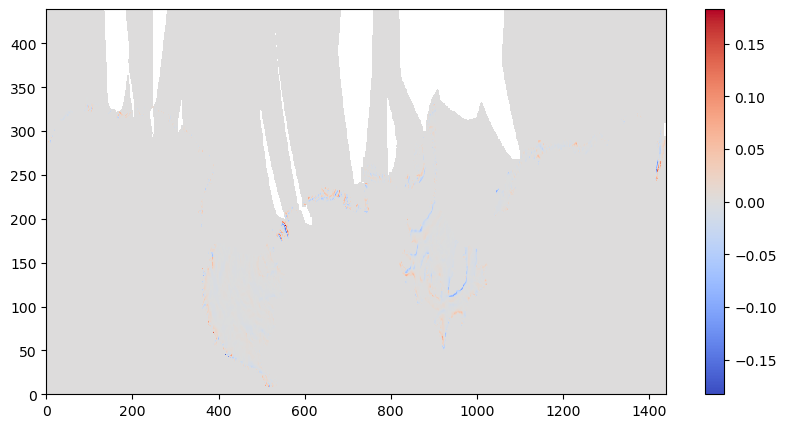

In [55]:
variable = 'slope_ba_across_front'
fig, ax = plt.subplots(1,1, figsize = (10,5))
im= plt.pcolor(B2[variable] - NEMO[variable], cmap = 'coolwarm')
min_diff = np.min(B2[variable] - NEMO[variable])
max_diff = np.max(B2[variable] - NEMO[variable])
clim = np.max((max_diff, -min_diff))
im.set_clim(-clim, clim)
plt.colorbar()
